In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_31.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_24.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_9.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_17.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_10.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_8.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_15.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_14.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_30.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_26.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_16.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_1.2.2026.listens.csv
/kaggle/input/datasets/js042710

Load dữ liệu và định hình lại thời gian

In [5]:
#IMPORT THƯ VIỆN VÀ CẤU HÌNH
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cấu hình đường dẫn
CONFIG = {
    'data_dir': '/kaggle/input/datasets/js042710/second3t1k/CLEARDATA'
}

print("Đã import thư viện và cấu hình thành công!")

Đã import thư viện và cấu hình thành công!


In [6]:
# ĐỌC VÀ GỘP DỮ LIỆU
print("MODULE 1: PHÂN CỤM NGƯỜI DÙNG")
print("\n 1. ĐANG ĐỌC VÀ GỘP DỮ LIỆU...")

# Lấy danh sách file
all_files = sorted(glob.glob(os.path.join(CONFIG['data_dir'], '*.csv')))
print(f"   Tìm thấy {len(all_files)} file CSV")

# Đọc từng file
df_list = []
cols_to_use = ['user_id', 'timestamp', 'recording_msid', 'artist_name']

for i, f in enumerate(all_files, 1):
    try:
        df_temp = pd.read_csv(f, usecols=cols_to_use)
        df_list.append(df_temp)
        if i % 5 == 0:  # In tiến độ mỗi 5 file
            print(f" Đã đọc {i}/{len(all_files)} files")
    except Exception as e:
        print(f"Lỗi đọc file {os.path.basename(f)}: {e}")

# Gộp dữ liệu
df_full = pd.concat(df_list, ignore_index=True)
del df_list  # Giải phóng bộ nhớ

# Xử lý timestamp
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

# Hiển thị thông tin
print(f"\nTổng số dòng logs: {df_full.shape[0]:,}")
print(f" Số user duy nhất: {df_full['user_id'].nunique():,}")
print(f" Khoảng thời gian: {df_full['timestamp'].min()} đến {df_full['timestamp'].max()}")
print(f" Dung lượng dữ liệu: {df_full.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

MODULE 1: PHÂN CỤM NGƯỜI DÙNG

 1. ĐANG ĐỌC VÀ GỘP DỮ LIỆU...
   Tìm thấy 29 file CSV
 Đã đọc 5/29 files
 Đã đọc 10/29 files
 Đã đọc 15/29 files
 Đã đọc 20/29 files
 Đã đọc 25/29 files

Tổng số dòng logs: 80,631,061
 Số user duy nhất: 23,376
 Khoảng thời gian: 2005-02-13 23:59:59 đến 2026-02-05 00:03:33
 Dung lượng dữ liệu: 12.29 GB


In [7]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False


 2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN...
Giờ cao điểm nghe: 16h
Tỷ lệ nghe đêm: 19.4%
Tỷ lệ nghe cuối tuần: 26.0%


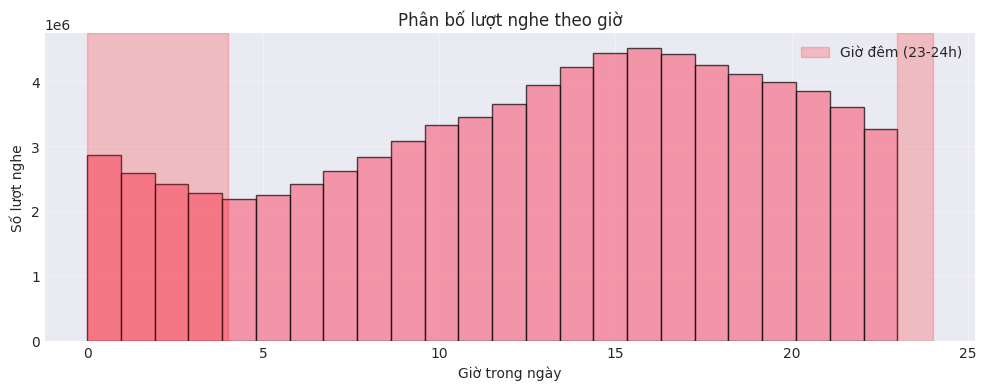

In [8]:
# FEATURE ENGINEERING - PHẦN 1 (ĐẶC TRƯNG THỜI GIAN)
print("\n 2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN...")

# Trích xuất đặc trưng thời gian
df_full['hour'] = df_full['timestamp'].dt.hour
df_full['day_of_week'] = df_full['timestamp'].dt.dayofweek
df_full['is_weekend'] = df_full['day_of_week'].isin([5, 6]).astype(int)
df_full['is_night'] = df_full['hour'].apply(lambda x: 1 if (x >= 23 or x <= 4) else 0)

# Thống kê nhanh
print(f"Giờ cao điểm nghe: {df_full['hour'].mode()[0]}h")
print(f"Tỷ lệ nghe đêm: {df_full['is_night'].mean()*100:.1f}%")
print(f"Tỷ lệ nghe cuối tuần: {df_full['is_weekend'].mean()*100:.1f}%")

# Hiển thị phân bố giờ nghe
plt.figure(figsize=(12, 4))
plt.hist(df_full['hour'], bins=24, alpha=0.7, edgecolor='black')
plt.axvspan(23, 24, alpha=0.2, color='red', label='Giờ đêm (23-24h)')
plt.axvspan(0, 4, alpha=0.2, color='red')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượt nghe')
plt.title('Phân bố lượt nghe theo giờ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
#FEATURE ENGINEERING - PHẦN 2 (TỔNG HỢP THEO USER)
print("\n 3. ĐANG TỔNG HỢP DỮ LIỆU THEO USER...")

# Kiểm tra các cột cần thiết
required_cols = ['user_id', 'recording_msid', 'artist_name', 'timestamp', 'is_night', 'is_weekend']
missing_cols = [col for col in required_cols if col not in df_full.columns]

if missing_cols:
    print(f"Thiếu các cột: {missing_cols}")
    print("Vui lòng chạy CELL 3 trước!")
else:
    # Tổng hợp cơ bản
    user_profile = df_full.groupby('user_id').agg(
        total_listens=('recording_msid', 'count'),
        unique_artists=('artist_name', 'nunique'),
        night_listens=('is_night', 'sum'),
        weekend_listens=('is_weekend', 'sum'),
        first_listen=('timestamp', 'min'),
        last_listen=('timestamp', 'max')
    ).reset_index()

    print(f" Đã tạo profile cơ bản cho {len(user_profile)} users")

    # Tính các tỷ lệ
    user_profile['night_ratio'] = user_profile['night_listens'] / user_profile['total_listens']
    user_profile['weekend_ratio'] = user_profile['weekend_listens'] / user_profile['total_listens']
    user_profile['artist_diversity'] = user_profile['unique_artists'] / user_profile['total_listens']

    # Tính số ngày hoạt động
    user_profile['active_days'] = (user_profile['last_listen'] - user_profile['first_listen']).dt.days + 1
    user_profile['avg_listens_per_day'] = user_profile['total_listens'] / user_profile['active_days']

    print(f"Đã tính các chỉ số tỷ lệ và cường độ")
    
    # Hiển thị thông tin
    print(f"\nKích thước user_profile: {user_profile.shape}")
    print(f"Các cột trong user_profile:")
    print(list(user_profile.columns))


 3. ĐANG TỔNG HỢP DỮ LIỆU THEO USER...
 Đã tạo profile cơ bản cho 23376 users
Đã tính các chỉ số tỷ lệ và cường độ

Kích thước user_profile: (23376, 12)
Các cột trong user_profile:
['user_id', 'total_listens', 'unique_artists', 'night_listens', 'weekend_listens', 'first_listen', 'last_listen', 'night_ratio', 'weekend_ratio', 'artist_diversity', 'active_days', 'avg_listens_per_day']


In [21]:
#FEATURE ENGINEERING - PHẦN 3 (LOYALTY SCORE)
print("\n 4. ĐANG TÍNH LOYALTY SCORE...")

# Kiểm tra dữ liệu đầu vào
print("    Kiểm tra dữ liệu:")
print(f"   - Số user trong user_profile: {len(user_profile)}")
print(f"   - Các cột hiện có: {list(user_profile.columns)}")

# Đếm số lượt nghe mỗi nghệ sĩ của từng user
print("\n    Đang đếm lượt nghe theo nghệ sĩ...")
artist_counts = df_full.groupby(['user_id', 'artist_name']).size().reset_index(name='count')
print(f"    Đã đếm xong: {len(artist_counts):,} dòng (user - artist)")

# Hiển thị thử vài dòng
print("\n    Ví dụ dữ liệu artist_counts:")
print(artist_counts.head(10))

# Tìm nghệ sĩ được nghe nhiều nhất của mỗi user
print("\n    Đang tìm nghệ sĩ được nghe nhiều nhất...")
top_artist_per_user = artist_counts.groupby('user_id')['count'].max().reset_index()
top_artist_per_user.columns = ['user_id', 'max_artist_listens']
print(f"    Đã tìm xong cho {len(top_artist_per_user)} users")

# Merge vào user_profile
print("\n    Đang ghép dữ liệu...")
user_profile = user_profile.merge(top_artist_per_user, on='user_id', how='left')
print(f"    Đã ghép xong")

# Tính loyalty score
print("\n    Đang tính loyalty score...")
user_profile['loyalty_score'] = user_profile['max_artist_listens'] / user_profile['total_listens']

# Đặc trưng về giờ cao điểm
print("\n    Đang tính giờ cao điểm...")
peak_hour = df_full.groupby('user_id')['hour'].agg(lambda x: x.mode()[0] if not x.mode().empty else -1)
user_profile['peak_hour'] = user_profile['user_id'].map(peak_hour)

# Xử lý giá trị thiếu
print("\n    Đang xử lý giá trị thiếu...")
user_profile = user_profile.fillna(0)

# Kiểm tra kết quả
print("\n    HOÀN THÀNH! Kết quả:")
print(f"   - Kích thước user_profile: {user_profile.shape}")
print(f"   - Các cột mới thêm: 'max_artist_listens', 'loyalty_score', 'peak_hour'")
print(f"\n    Thống kê loyalty_score:")
print(f"   - Min: {user_profile['loyalty_score'].min():.3f}")
print(f"   - Max: {user_profile['loyalty_score'].max():.3f}")
print(f"   - Mean: {user_profile['loyalty_score'].mean():.3f}")
print(f"   - Median: {user_profile['loyalty_score'].median():.3f}")




 4. ĐANG TÍNH LOYALTY SCORE...
    Kiểm tra dữ liệu:
   - Số user trong user_profile: 23376
   - Các cột hiện có: ['user_id', 'total_listens', 'unique_artists', 'night_listens', 'weekend_listens', 'first_listen', 'last_listen', 'night_ratio', 'weekend_ratio', 'artist_diversity', 'active_days', 'avg_listens_per_day']

    Đang đếm lượt nghe theo nghệ sĩ...
    Đã đếm xong: 7,772,354 dòng (user - artist)

    Ví dụ dữ liệu artist_counts:
   user_id                                        artist_name  count
0        1                                         Ben Böhmer      1
1        1                                   Boards of Canada      1
2        1                               Bonobo, Jamila Woods      1
3        1                             Carbon Based Lifeforms     28
4        1        Carbon Based Lifeforms feat. Ester Nannmark      5
5        1              Carbon Based Lifeforms feat. Karin My     16
6        1  Carbon Based Lifeforms feat. Not Lars & Ester ...      3
7      

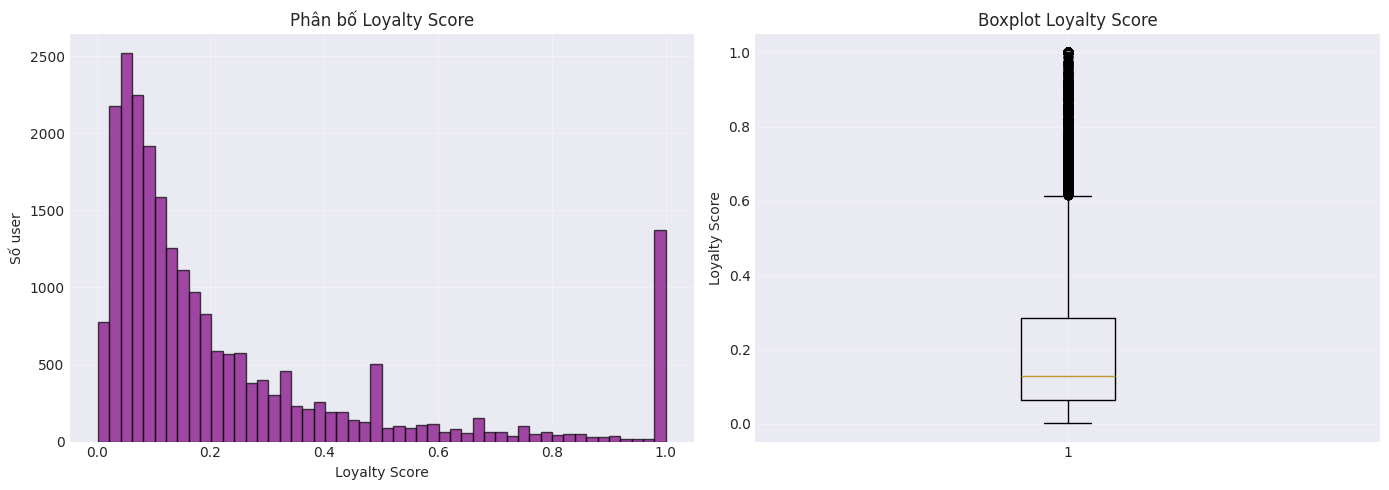


    10 user đầu tiên trong user_profile:


,user_id,total_listens,max_artist_listens,loyalty_score,peak_hour
0,1,255,34,0.133333,15
1,5,1530,35,0.022876,7
2,9,11,6,0.545455,13
3,10,57,45,0.789474,19
4,11,521,39,0.074856,19
5,13,2530,86,0.033992,22
6,20,394,129,0.327411,23
7,21,5392,2373,0.440096,11
8,23,3,1,0.333333,4
9,24,2537,322,0.126922,16



    Phân loại sơ bộ theo loyalty_score:
   - Rất thấp: 15,347 users (65.7%)
   - Thấp: 3,997 users (17.1%)
   - Trung bình: 1,650 users (7.1%)
   - Cao: 725 users (3.1%)
   - Rất cao: 1,657 users (7.1%)


In [22]:
# Hiển thị phân bố loyalty_score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(user_profile['loyalty_score'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[0].set_xlabel('Loyalty Score')
axes[0].set_ylabel('Số user')
axes[0].set_title('Phân bố Loyalty Score')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(user_profile['loyalty_score'])
axes[1].set_ylabel('Loyalty Score')
axes[1].set_title('Boxplot Loyalty Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị 10 user đầu tiên
print("\n    10 user đầu tiên trong user_profile:")
display(user_profile[['user_id', 'total_listens', 'max_artist_listens', 'loyalty_score', 'peak_hour']].head(10))

# Thống kê theo khoảng loyalty_score
print("\n    Phân loại sơ bộ theo loyalty_score:")
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']
user_profile['loyalty_level'] = pd.cut(user_profile['loyalty_score'], bins=bins, labels=labels)
loyalty_dist = user_profile['loyalty_level'].value_counts().sort_index()

for level, count in loyalty_dist.items():
    percentage = count / len(user_profile) * 100
    print(f"   - {level}: {count:,} users ({percentage:.1f}%)")

# Xóa cột tạm
user_profile = user_profile.drop('loyalty_level', axis=1)


 5. LỰA CHỌN FEATURES CHO PHÂN CỤM...

  Thống kê mô tả features:


,total_listens,night_ratio,weekend_ratio,artist_diversity,avg_listens_per_day,loyalty_score
count,23376.000,23376.000,23376.000,23376.000,23376.000,23376.000
mean,3449.310,0.194,0.258,0.373,25.133,0.233
std,24180.107,0.225,0.224,0.270,38.326,0.259
min,1.000,0.000,0.000,0.001,0.001,0.002
25%,70.000,0.002,0.103,0.160,5.000,0.065
50%,329.000,0.124,0.233,0.306,13.789,0.129
75%,917.000,0.310,0.334,0.519,31.000,0.284
max,1264311.000,1.000,1.000,1.000,861.960,1.000


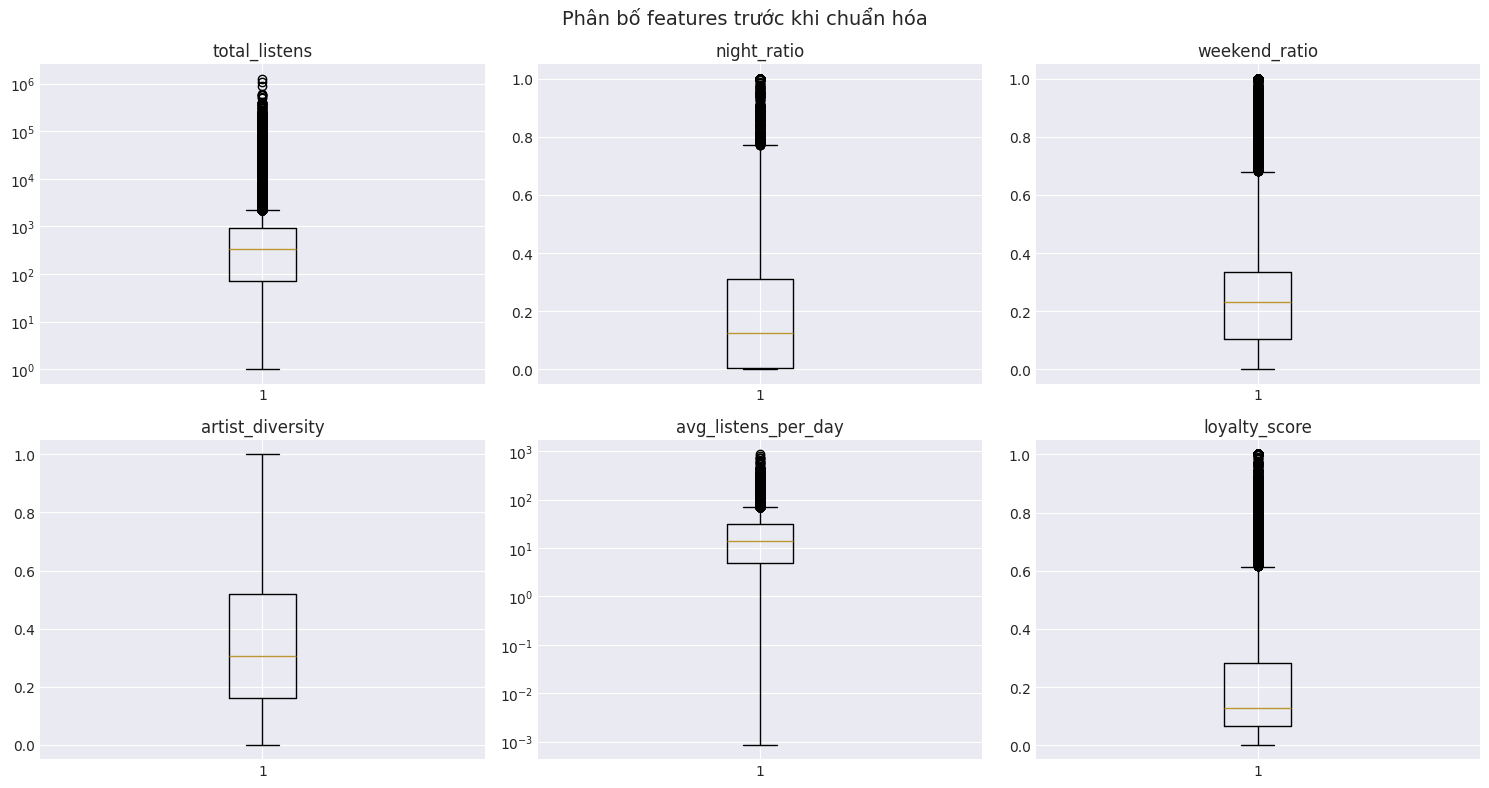


 6. CHUẨN HÓA DỮ LIỆU...
 Đã chuẩn hóa dữ liệu về mean=0, std=1
 Kích thước X_scaled: (23376, 6)


In [23]:
#LỰA CHỌN FEATURES VÀ CHUẨN HÓA
print("\n 5. LỰA CHỌN FEATURES CHO PHÂN CỤM...")

# Danh sách features chính
features = [
    'total_listens',           # Tổng lượt nghe
    'night_ratio',             # Tỷ lệ nghe đêm
    'weekend_ratio',           # Tỷ lệ nghe cuối tuần
    'artist_diversity',        # Đa dạng nghệ sĩ
    'avg_listens_per_day',     # Cường độ nghe
    'loyalty_score'            # Độ trung thành
]

# Tạo ma trận features
X = user_profile[features].copy()

# Thống kê mô tả
print("\n  Thống kê mô tả features:")
display(X.describe().round(3))

# Vẽ boxplot trước khi chuẩn hóa
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].boxplot(X[feature])
    axes[i].set_title(feature)
    axes[i].set_yscale('log' if feature in ['total_listens', 'avg_listens_per_day'] else 'linear')

plt.suptitle('Phân bố features trước khi chuẩn hóa', fontsize=14)
plt.tight_layout()
plt.show()

# Chuẩn hóa dữ liệu
print("\n 6. CHUẨN HÓA DỮ LIỆU...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=user_profile['user_id'])

print(" Đã chuẩn hóa dữ liệu về mean=0, std=1")
print(f" Kích thước X_scaled: {X_scaled.shape}")


 7. TÌM SỐ CLUSTER TỐI ƯU...
   Đang chạy K=2... Inertia=119967, Silhouette=0.370
   Đang chạy K=3... Inertia=106122, Silhouette=0.387
   Đang chạy K=4... Inertia=92515, Silhouette=0.322
   Đang chạy K=5... Inertia=82146, Silhouette=0.243
   Đang chạy K=6... Inertia=70963, Silhouette=0.246
   Đang chạy K=7... Inertia=63336, Silhouette=0.226


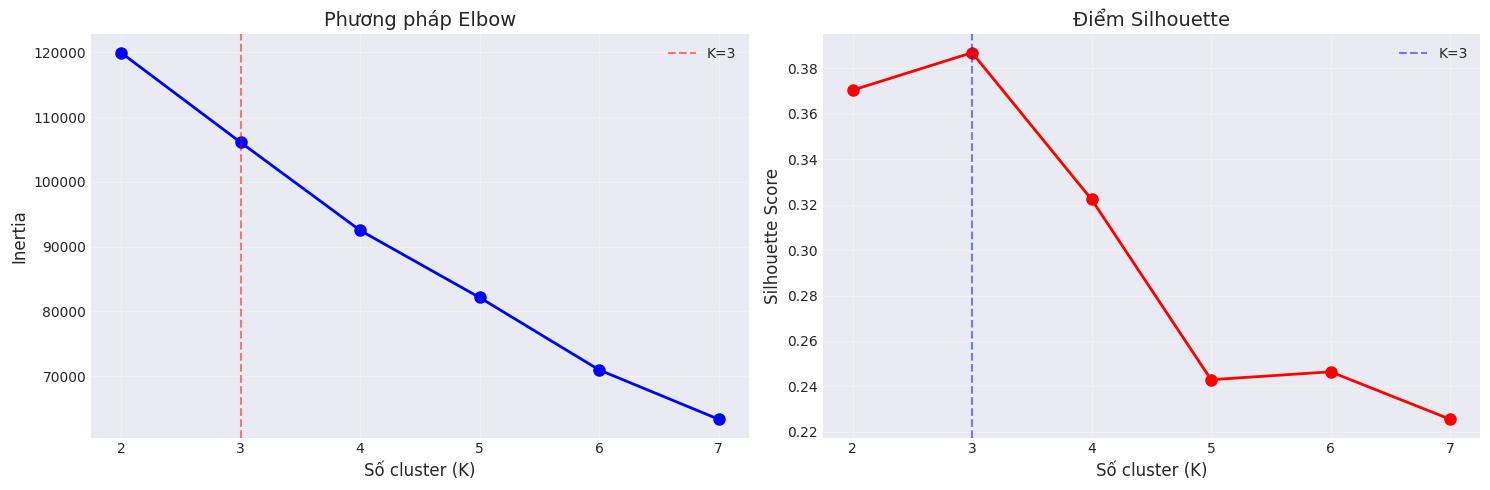

In [25]:
#TÌM SỐ CLUSTER TỐI ƯU
print("\n 7. TÌM SỐ CLUSTER TỐI ƯU...")

inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    print(f"   Đang chạy K={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"Inertia={kmeans.inertia_:.0f}, Silhouette={sil_score:.3f}")

# Vẽ biểu đồ Elbow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Số cluster (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Phương pháp Elbow', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='K=3')
ax1.legend()

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Số cluster (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Điểm Silhouette', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=3, color='blue', linestyle='--', alpha=0.5, label='K=3')
ax2.legend()

plt.tight_layout()
plt.show()



In [26]:
# Chọn K tối ưu
optimal_k = 3
print(f"\n Chọn K={optimal_k} dựa trên Elbow method và Silhouette score")


 Chọn K=3 dựa trên Elbow method và Silhouette score



 8. ĐANG CHẠY K-MEANS VỚI K=3...

 9. PHÂN TÍCH ĐẶC ĐIỂM CÁC CỤM...

   Giá trị trung bình của các cụm (chưa chuẩn hóa):


,total_listens,night_ratio,weekend_ratio,artist_diversity,avg_listens_per_day,loyalty_score
cluster,,,,,,
0,1742.135,0.187,0.248,0.338,28.480,0.144
1,61.438,0.235,0.316,0.593,5.192,0.740
2,176057.046,0.182,0.258,0.062,43.842,0.036


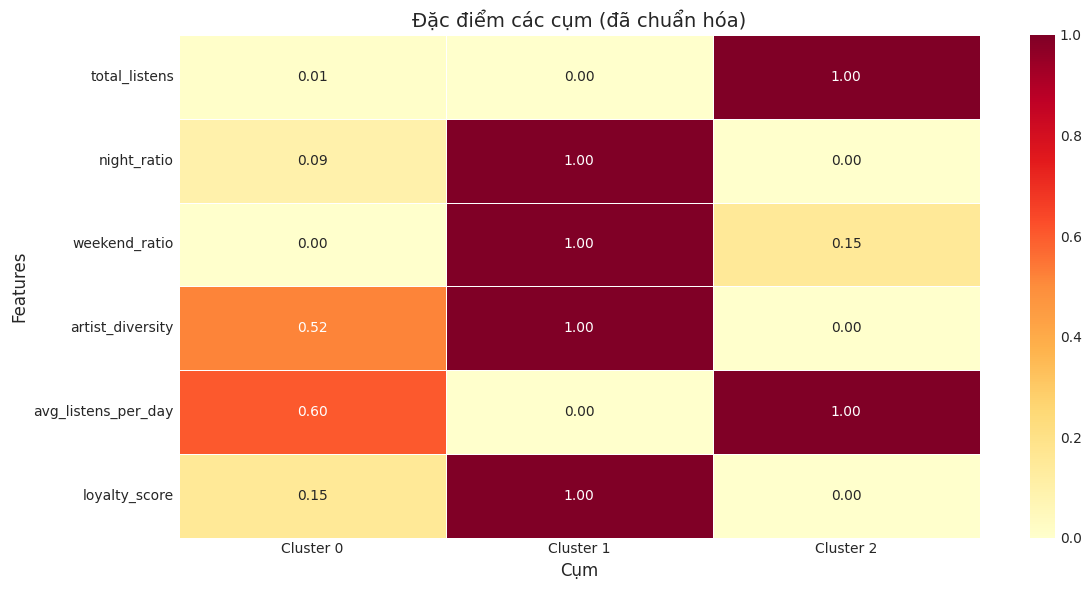

In [27]:
# CHẠY K-MEANS VÀ PHÂN TÍCH CỤM
print(f"\n 8. ĐANG CHẠY K-MEANS VỚI K={optimal_k}...")

# Chạy K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
user_profile['cluster'] = kmeans.fit_predict(X_scaled)

# Phân tích đặc điểm các cụm
print("\n 9. PHÂN TÍCH ĐẶC ĐIỂM CÁC CỤM...")

# Tính trung bình các features theo cluster
cluster_centers = user_profile.groupby('cluster')[features].mean()
print("\n   Giá trị trung bình của các cụm (chưa chuẩn hóa):")
display(cluster_centers.round(3))

# Chuẩn hóa để so sánh
cluster_centers_normalized = cluster_centers.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

# Vẽ heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers_normalized.T, annot=True, cmap='YlOrRd', 
            xticklabels=[f'Cluster {i}' for i in range(optimal_k)],
            fmt='.2f', linewidths=0.5)
plt.title('Đặc điểm các cụm (đã chuẩn hóa)', fontsize=14)
plt.xlabel('Cụm', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()


 10. ĐANG GÁN NHÃN CHO CÁC CỤM...

 KẾT QUẢ PHÂN LOẠI:
--------------------------------------------------
 NGƯỜI MỚI:
   - Số lượng: 19,580 người dùng (83.8%)
   - Mô tả: Mới tham gia, lượt nghe còn ít

 CÚ ĐÊM:
   - Số lượng: 3,533 người dùng (15.1%)
   - Mô tả: Thích nghe nhạc ban đêm, hoạt động về khuya

CLUSTER 2:
   - Số lượng: 263 người dùng (1.1%)
   - Mô tả: Nhóm người dùng đặc biệt



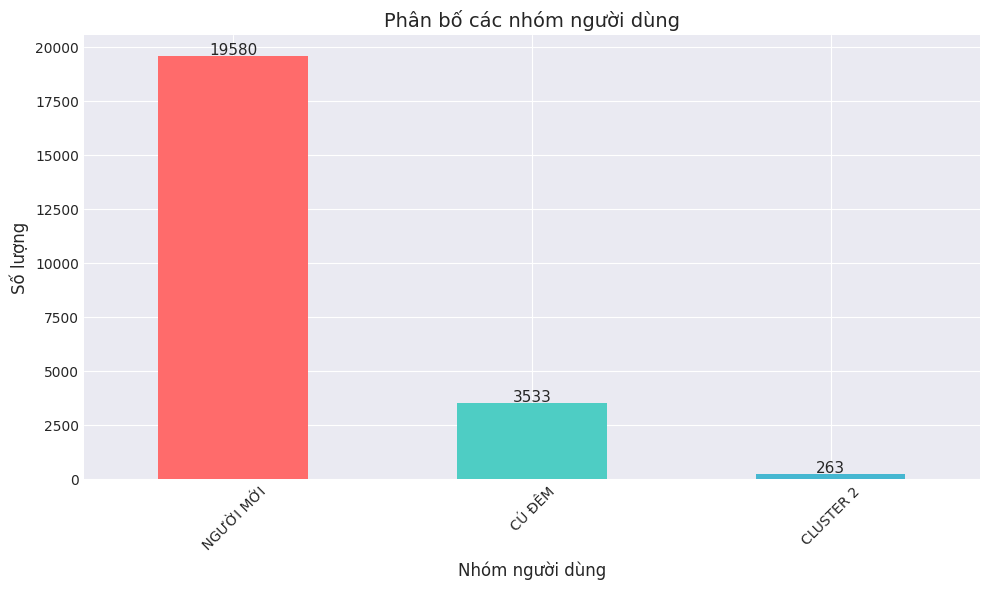

In [28]:
#GÁN NHÃN CHO CÁC CỤM
print("\n 10. ĐANG GÁN NHÃN CHO CÁC CỤM...")

# Phân tích logic để gán nhãn
cluster_labels = {}
label_descriptions = {}

for cluster_id in range(optimal_k):
    row = cluster_centers.loc[cluster_id]
    
    # Tính điểm cho từng tiêu chí
    night_score = row['night_ratio'] / cluster_centers['night_ratio'].max()
    loyalty_score_val = row['loyalty_score'] / cluster_centers['loyalty_score'].max()
    volume_score = row['total_listens'] / cluster_centers['total_listens'].max()
    diversity_score = 1 - (row['artist_diversity'] / cluster_centers['artist_diversity'].max())  # Đa dạng càng thấp càng trung thành
    
    # Tổng hợp điểm
    is_night_owl = night_score > 0.8
    is_super_fan = loyalty_score_val > 0.7 and volume_score > 0.3
    is_newbie = volume_score < 0.2
    is_balanced = 0.2 <= volume_score <= 0.6
    
    # Gán nhãn dựa trên điểm mạnh nhất
    if is_night_owl:
        cluster_labels[cluster_id] = " CÚ ĐÊM"
        label_descriptions[cluster_id] = "Thích nghe nhạc ban đêm, hoạt động về khuya"
    elif is_super_fan:
        cluster_labels[cluster_id] = " FAN CỨNG"
        label_descriptions[cluster_id] = "Nghe nhiều, trung thành với một vài nghệ sĩ"
    elif is_newbie:
        cluster_labels[cluster_id] = " NGƯỜI MỚI"
        label_descriptions[cluster_id] = "Mới tham gia, lượt nghe còn ít"
    elif is_balanced:
        cluster_labels[cluster_id] = " NGHE THÔNG THƯỜNG"
        label_descriptions[cluster_id] = "Thói quen nghe nhạc cân bằng, đa dạng"
    else:
        cluster_labels[cluster_id] = f"CLUSTER {cluster_id}"
        label_descriptions[cluster_id] = "Nhóm người dùng đặc biệt"

# Gán nhãn
user_profile['User_Type'] = user_profile['cluster'].map(cluster_labels)

# Hiển thị kết quả
print("\n KẾT QUẢ PHÂN LOẠI:")
print("-" * 50)
type_distribution = user_profile['User_Type'].value_counts()
for user_type, count in type_distribution.items():
    percentage = count / len(user_profile) * 100
    cluster_id = user_profile[user_profile['User_Type'] == user_type]['cluster'].iloc[0]
    print(f"{user_type}:")
    print(f"   - Số lượng: {count:,} người dùng ({percentage:.1f}%)")
    print(f"   - Mô tả: {label_descriptions[cluster_id]}")
    print()

# Vẽ biểu đồ phân bố
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
type_distribution.plot(kind='bar', color=colors[:len(type_distribution)])
plt.title('Phân bố các nhóm người dùng', fontsize=14)
plt.xlabel('Nhóm người dùng', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(type_distribution):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


 11. TRỰC QUAN HÓA PHÂN BỐ FEATURES...


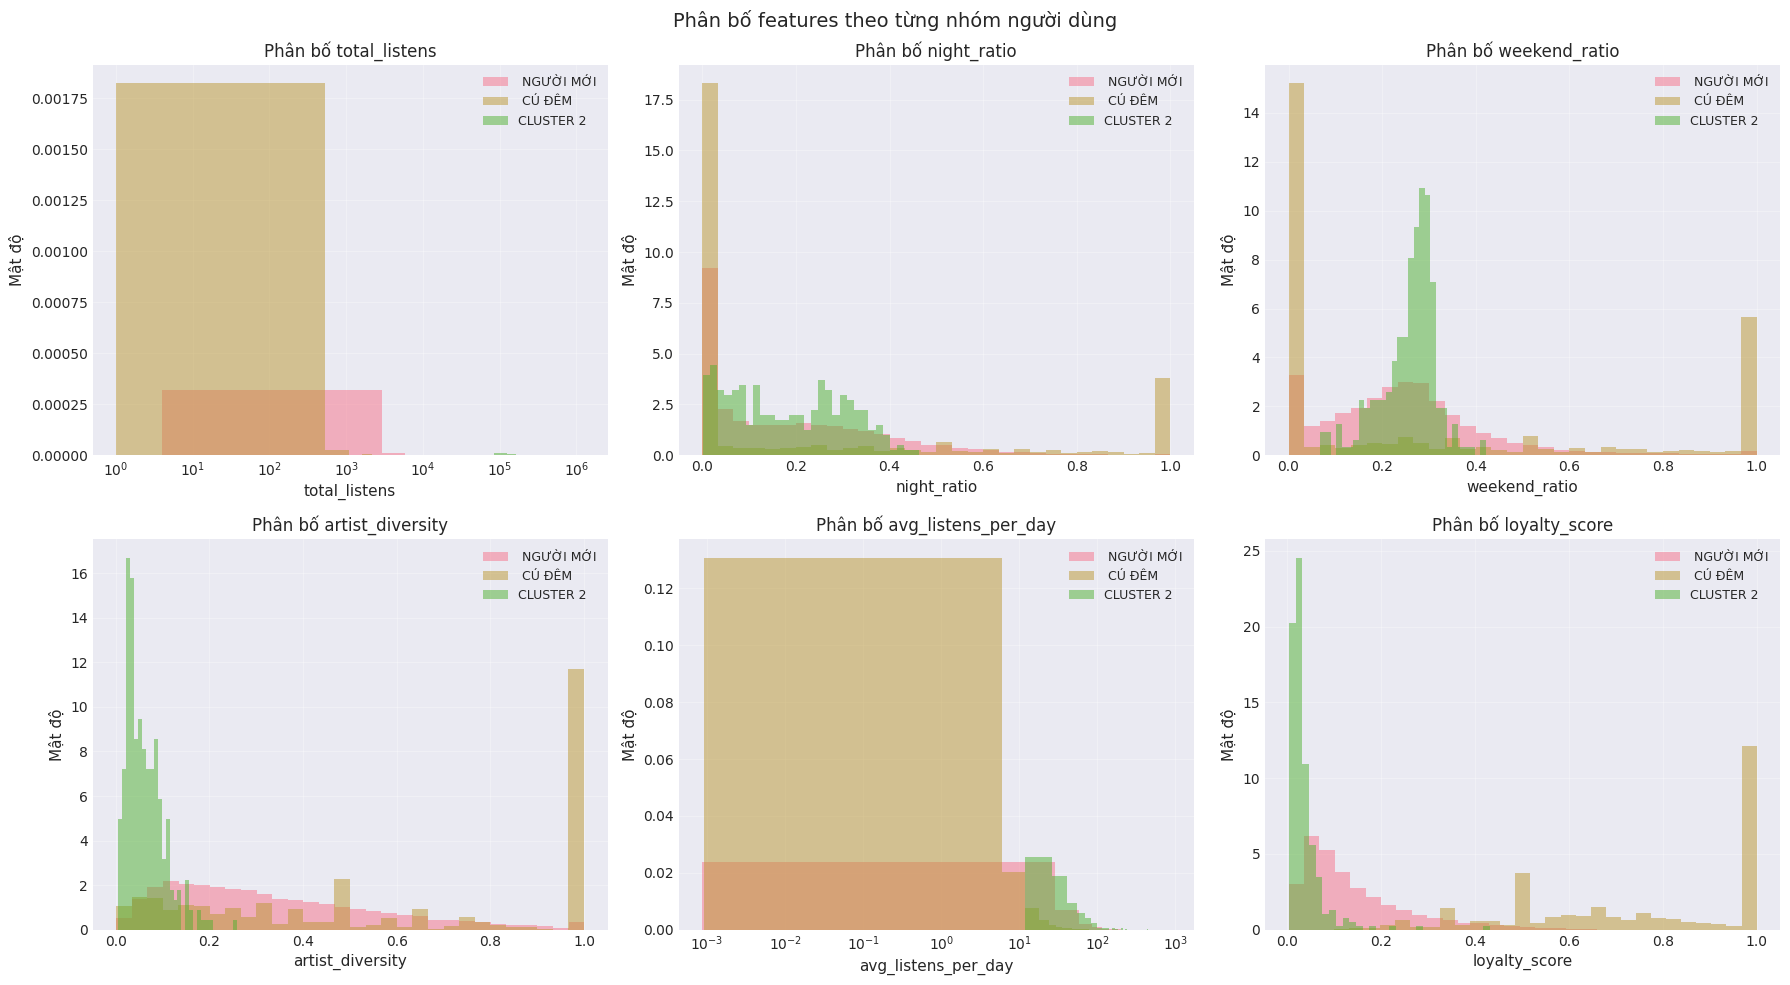

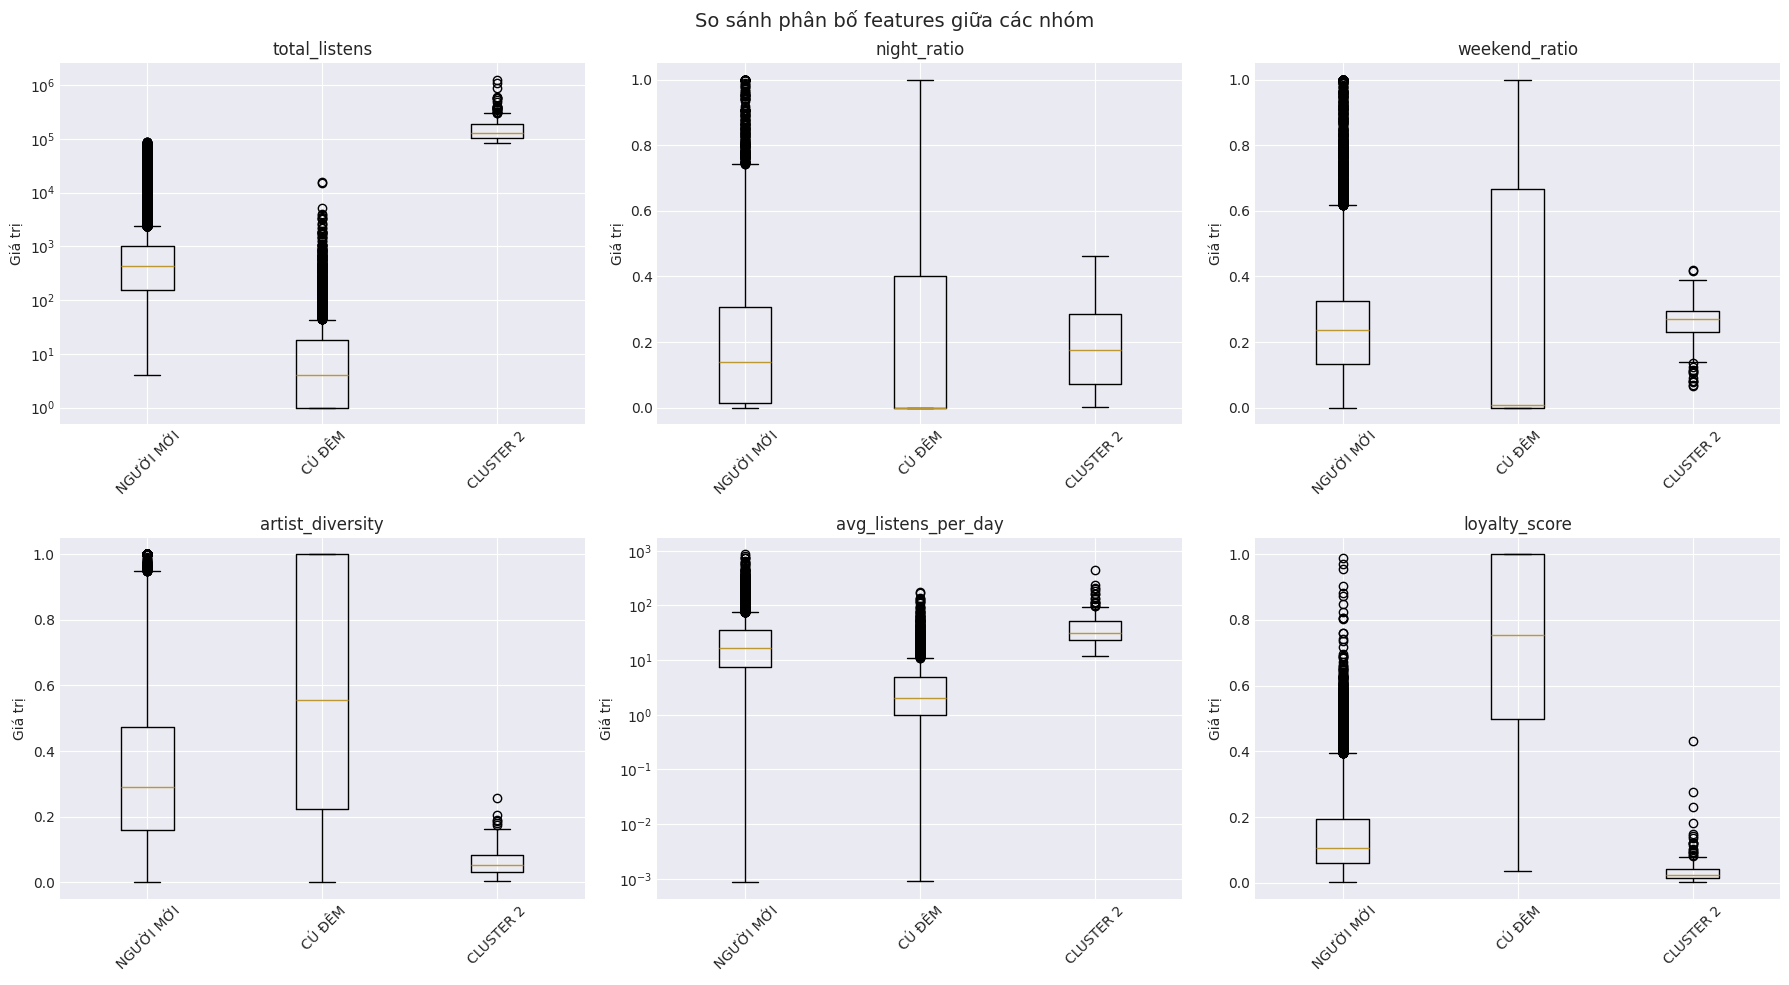

In [30]:
#TRỰC QUAN HÓA PHÂN BỐ FEATURES THEO CỤM
print("\n 11. TRỰC QUAN HÓA PHÂN BỐ FEATURES...")

# Histogram cho từng feature
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    for cluster_id in range(optimal_k):
        cluster_data = user_profile[user_profile['cluster'] == cluster_id][feature]
        axes[i].hist(cluster_data, bins=30, alpha=0.5, 
                    label=f'{cluster_labels[cluster_id]}', density=True)
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Mật độ', fontsize=11)
    axes[i].set_title(f'Phân bố {feature}', fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    
    # Log scale cho các feature có giá trị lớn
    if feature in ['total_listens', 'avg_listens_per_day']:
        axes[i].set_xscale('log')

plt.suptitle('Phân bố features theo từng nhóm người dùng', fontsize=14)
plt.tight_layout()
plt.show()

# Boxplot so sánh
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    data_to_plot = [user_profile[user_profile['cluster'] == cluster_id][feature] 
                    for cluster_id in range(optimal_k)]
    bp = axes[i].boxplot(data_to_plot, labels=[cluster_labels[cid] for cid in range(optimal_k)])
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_ylabel('Giá trị', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Log scale cho các feature có giá trị lớn
    if feature in ['total_listens', 'avg_listens_per_day']:
        axes[i].set_yscale('log')

plt.suptitle('So sánh phân bố features giữa các nhóm', fontsize=14)
plt.tight_layout()
plt.show()


 12. TRỰC QUAN HÓA KHÔNG GIAN 2D VỚI PCA...


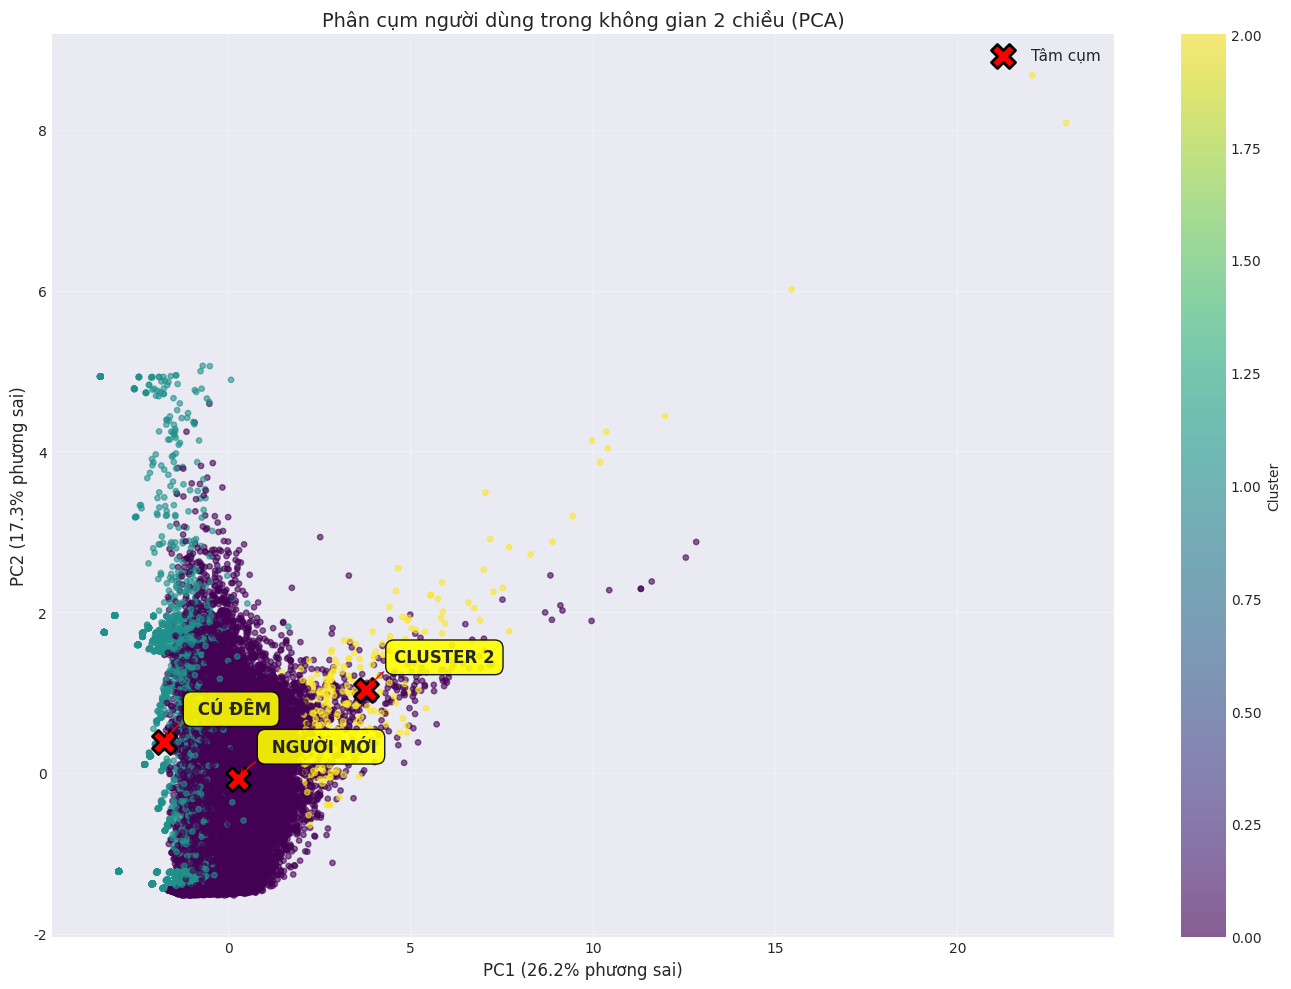


 Tổng phương sai giải thích được: 43.6%


In [32]:
# PCA VISUALIZATION
print("\n 12. TRỰC QUAN HÓA KHÔNG GIAN 2D VỚI PCA...")

# Giảm chiều dữ liệu
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame cho visualization
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': user_profile['cluster'],
    'User_Type': user_profile['User_Type']
})

# Vẽ biểu đồ PCA
plt.figure(figsize=(14, 10))

# Scatter plot với màu sắc theo cluster
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
                     c=pca_df['Cluster'], cmap='viridis', 
                     alpha=0.6, s=15)

# Vẽ tâm cụm
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           marker='X', s=300, c='red', edgecolors='black', 
           linewidths=2, label='Tâm cụm')

# Thêm nhãn cho các cụm
for i, (x, y) in enumerate(centers_pca):
    plt.annotate(cluster_labels[i], (x, y), 
                xytext=(20, 20), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.9),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='red'))

plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} phương sai)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} phương sai)', fontsize=12)
plt.title('Phân cụm người dùng trong không gian 2 chiều (PCA)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Tổng phương sai giải thích được: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [35]:
#THỐNG KÊ CHI TIẾT THEO NHÓM
print("\n 13. THỐNG KÊ CHI TIẾT THEO NHÓM...")

# Tạo bảng thống kê
stats_list = []
for cluster_id in range(optimal_k):
    cluster_data = user_profile[user_profile['cluster'] == cluster_id]
    
    stats = {
        'Nhóm': cluster_labels[cluster_id],
        'Số lượng': len(cluster_data),
        'Tổng lượt nghe (TB)': f"{cluster_data['total_listens'].mean():,.0f}",
        'Tỷ lệ nghe đêm (TB)': f"{cluster_data['night_ratio'].mean()*100:.1f}%",
        'Đa dạng nghệ sĩ (TB)': f"{cluster_data['artist_diversity'].mean():.3f}",
        'Loyalty Score (TB)': f"{cluster_data['loyalty_score'].mean():.3f}",
        'Ngày hoạt động (TB)': f"{cluster_data['active_days'].mean():.0f}",
        'Lượt nghe/ngày (TB)': f"{cluster_data['avg_listens_per_day'].mean():.1f}"
    }
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)
print("\n BẢNG THỐNG KÊ CHI TIẾT:")
display(stats_df)

# Tìm user đặc trưng nhất mỗi nhóm
print("\n USER ĐẶC TRƯNG NHẤT MỖI NHÓM:")
for cluster_id in range(optimal_k):
    cluster_data = user_profile[user_profile['cluster'] == cluster_id]
    
    # Tính điểm đặc trưng (kết hợp nhiều tiêu chí)
    cluster_data['representative_score'] = (
        cluster_data['night_ratio'] / cluster_centers.loc[cluster_id, 'night_ratio'] +
        cluster_data['loyalty_score'] / cluster_centers.loc[cluster_id, 'loyalty_score'] +
        cluster_data['total_listens'] / cluster_centers.loc[cluster_id, 'total_listens']
    ) / 3
    
    representative_user = cluster_data.nlargest(1, 'representative_score').iloc[0]
    
    print(f"\n{cluster_labels[cluster_id]}:")
    print(f"   - User ID: {representative_user['user_id']}")
    print(f"   - Tổng lượt nghe: {representative_user['total_listens']:,.0f}")
    print(f"   - Tỷ lệ nghe đêm: {representative_user['night_ratio']*100:.1f}%")
    print(f"   - Loyalty Score: {representative_user['loyalty_score']:.3f}")


 13. THỐNG KÊ CHI TIẾT THEO NHÓM...

 BẢNG THỐNG KÊ CHI TIẾT:


,Nhóm,Số lượng,Tổng lượt nghe (TB),Tỷ lệ nghe đêm (TB),Đa dạng nghệ sĩ (TB),Loyalty Score (TB),Ngày hoạt động (TB),Lượt nghe/ngày (TB)
0,NGƯỜI MỚI,19580,"1,742",18.7%,0.338,0.144,125,28.5
1,CÚ ĐÊM,3533,61,23.5%,0.593,0.740,8,5.2
2,CLUSTER 2,263,"176,057",18.2%,0.062,0.036,4831,43.8



 USER ĐẶC TRƯNG NHẤT MỖI NHÓM:

 NGƯỜI MỚI:
   - User ID: 85878
   - Tổng lượt nghe: 87,430
   - Tỷ lệ nghe đêm: 34.8%
   - Loyalty Score: 0.010

 CÚ ĐÊM:
   - User ID: 89868
   - Tổng lượt nghe: 16,109
   - Tỷ lệ nghe đêm: 4.5%
   - Loyalty Score: 0.733

CLUSTER 2:
   - User ID: 88629
   - Tổng lượt nghe: 96,671
   - Tỷ lệ nghe đêm: 35.7%
   - Loyalty Score: 0.431


In [36]:
# CELL 13: LƯU KẾT QUẢ
print("\n 14. LƯU KẾT QUẢ...")

# Tạo thư mục output nếu chưa có
os.makedirs('/kaggle/working/output', exist_ok=True)

# 1. Lưu profile đầy đủ
output_profile = user_profile[['user_id', 'cluster', 'User_Type'] + features + ['active_days', 'peak_hour']].copy()
output_profile.to_csv('/kaggle/working/output/user_clusters.csv', index=False)
print(f" Đã lưu user_clusters.csv ({len(output_profile):,} users)")

# 2. Lưu thống kê
stats_summary = pd.DataFrame({
    'Cluster': list(cluster_labels.keys()),
    'User_Type': list(cluster_labels.values()),
    'Count': type_distribution.values,
    'Percentage': (type_distribution.values / len(user_profile) * 100).round(1)
})
stats_summary.to_csv('/kaggle/working/output/cluster_statistics.csv', index=False)
print(f" Đã lưu cluster_statistics.csv")

# 3. Lưu đặc trưng các cụm
cluster_centers.to_csv('/kaggle/working/output/cluster_centers.csv')
print(f" Đã lưu cluster_centers.csv")

# 4. Lưu scaler để dùng cho module sau
import joblib
joblib.dump(scaler, '/kaggle/working/output/scaler.pkl')
joblib.dump(kmeans, '/kaggle/working/output/kmeans_model.pkl')
print(f" Đã lưu scaler.pkl và kmeans_model.pkl")

print(f"\n Tất cả kết quả được lưu trong: /kaggle/working/output/")


 14. LƯU KẾT QUẢ...
 Đã lưu user_clusters.csv (23,376 users)
 Đã lưu cluster_statistics.csv
 Đã lưu cluster_centers.csv
 Đã lưu scaler.pkl và kmeans_model.pkl

 Tất cả kết quả được lưu trong: /kaggle/working/output/


In [39]:
# CELL 14: TỔNG KẾT
print("MODULE 1: PHÂN CỤM NGƯỜI DÙNG")

# Hiển thị tóm tắt

total_users = len(user_profile)
print(f"Tổng số người dùng: {total_users:,}")

print("\nPhân bố nhóm:")
for user_type, count in type_distribution.items():
    percentage = count / total_users * 100
    print(f"  {user_type}: {count:>6,} ({percentage:>5.1f}%)")

print("\n ĐẶC TRƯNG NỔI BẬT:")
for cluster_id in range(optimal_k):
    print(f"\n{cluster_labels[cluster_id]}:")
    center = cluster_centers.loc[cluster_id]
    print(f"  - Nghe nhiều nhất vào: {user_profile[user_profile['cluster']==cluster_id]['peak_hour'].mode()[0]:.0f}h")
    if center['night_ratio'] > 0.2:
        print(f"  - Đặc điểm: Thích nghe đêm ({center['night_ratio']*100:.1f}%)")
    if center['loyalty_score'] > 0.5:
        print(f"  - Đặc điểm: Rất trung thành với nghệ sĩ yêu thích")
    if center['artist_diversity'] < 0.1:
        print(f"  - Đặc điểm: Tập trung nghe một số nghệ sĩ nhất định")

print("\n HOÀN THÀNH")

MODULE 1: PHÂN CỤM NGƯỜI DÙNG
Tổng số người dùng: 23,376

Phân bố nhóm:
   NGƯỜI MỚI: 19,580 ( 83.8%)
   CÚ ĐÊM:  3,533 ( 15.1%)
  CLUSTER 2:    263 (  1.1%)

 ĐẶC TRƯNG NỔI BẬT:

 NGƯỜI MỚI:
  - Nghe nhiều nhất vào: 16h

 CÚ ĐÊM:
  - Nghe nhiều nhất vào: 17h
  - Đặc điểm: Thích nghe đêm (23.5%)
  - Đặc điểm: Rất trung thành với nghệ sĩ yêu thích

CLUSTER 2:
  - Nghe nhiều nhất vào: 15h
  - Đặc điểm: Tập trung nghe một số nghệ sĩ nhất định

 HOÀN THÀNH
